# Taller de Inteligencia Artificial con TensorFlow
## Caso: Predicción de Diabetes con Red Neuronal

**Propósito:** Aplicar el ciclo básico de una solución de IA: carga de datos, preparación, entrenamiento, evaluación y predicción.

**Dataset:** `diabetes_prediction_dataset.csv` — 100.000 registros de pacientes con variables clínicas para predecir si un paciente tiene diabetes.

**Variable objetivo:**
- `diabetes`: 0 = No tiene diabetes / 1 = Tiene diabetes

**Variables de entrada:**
- `gender` — Sexo del paciente (Female, Male, Other)
- `age` — Edad en años
- `hypertension` — Hipertensión (0/1)
- `heart_disease` — Enfermedad cardíaca (0/1)
- `smoking_history` — Historial de tabaquismo
- `bmi` — Índice de masa corporal
- `HbA1c_level` — Nivel de hemoglobina glicosilada
- `blood_glucose_level` — Nivel de glucosa en sangre


## 1. Librerías necesarias

Importamos herramientas para manejo de datos, preprocesamiento, construcción del modelo y visualización.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)
print("Numpy:", np.__version__)
print("Pandas:", pd.__version__)


TensorFlow: 2.20.0
Numpy: 2.0.2
Pandas: 2.2.2


## 2. Carga del Dataset

Cargamos el archivo CSV con los datos reales de pacientes.

In [ ]:
from google.colab import files
import os

# Verifica si el archivo existe. Si no, solicita al usuario que lo suba.
if not os.path.exists("diabetes_prediction_dataset.csv"):
    print("El archivo 'diabetes_prediction_dataset.csv' no se encuentra. Por favor, súbelo.")
    try:
        uploaded = files.upload()
        if "diabetes_prediction_dataset.csv" not in uploaded:
            raise FileNotFoundError("El archivo 'diabetes_prediction_dataset.csv' no fue subido.")
    except Exception as e:
        print(f"Error al subir el archivo: {e}")
        # Considerar un 'sys.exit()' o un manejo de error más robusto aquí

df = pd.read_csv("diabetes_prediction_dataset.csv")

print("Forma del dataset:", df.shape)
print()
print("Primeras filas:")
df.head()

Forma del dataset: (100000, 9)

Primeras filas:


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


## 3. Exploración inicial de datos

Antes de entrenar, debemos observar y entender los datos.

In [ ]:
# Estadísticas descriptivas
df.describe()


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [ ]:
# Tipos de variables
print("Tipos de datos:")
print(df.dtypes)
print()
print("Valores nulos por columna:")
print(df.isnull().sum())


Tipos de datos:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

Valores nulos por columna:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


Distribución de diabetes:
diabetes
0    91500
1     8500
Name: count, dtype: int64



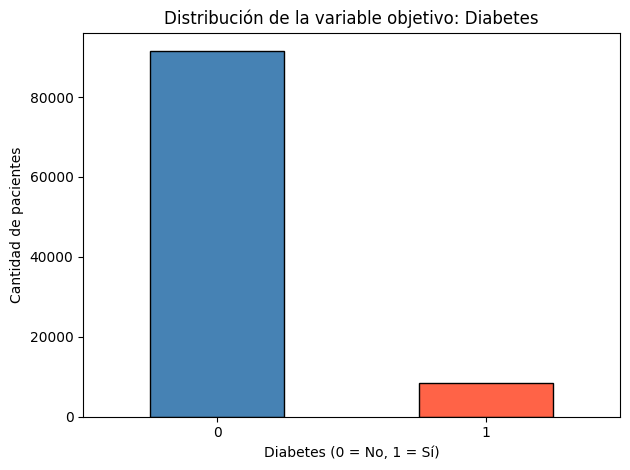

In [ ]:
# Distribución de la variable objetivo
print("Distribución de diabetes:")
print(df['diabetes'].value_counts())
print()
conteo = df['diabetes'].value_counts()
conteo.plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
plt.title("Distribución de la variable objetivo: Diabetes")
plt.xlabel("Diabetes (0 = No, 1 = Sí)")
plt.ylabel("Cantidad de pacientes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


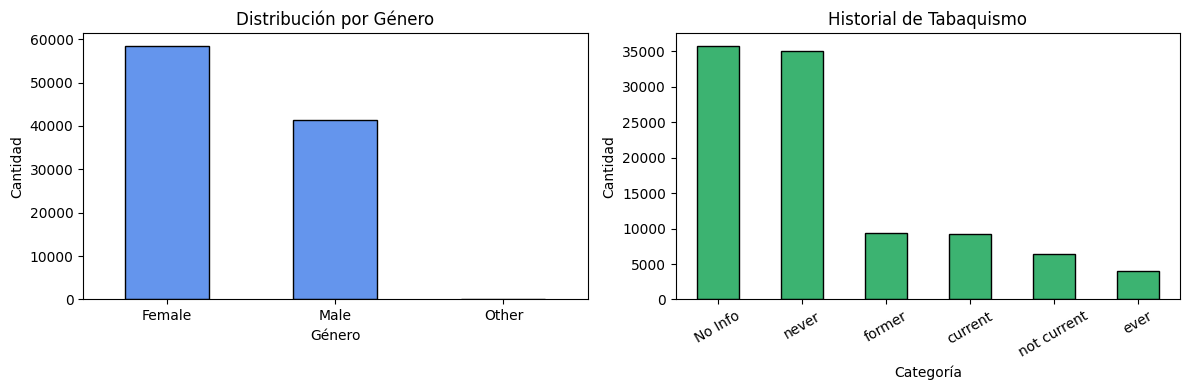

In [ ]:
# Distribución de variables categóricas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['gender'].value_counts().plot(kind='bar', ax=axes[0], color='cornflowerblue', edgecolor='black')
axes[0].set_title("Distribución por Género")
axes[0].set_xlabel("Género")
axes[0].set_ylabel("Cantidad")
axes[0].tick_params(axis='x', rotation=0)

df['smoking_history'].value_counts().plot(kind='bar', ax=axes[1], color='mediumseagreen', edgecolor='black')
axes[1].set_title("Historial de Tabaquismo")
axes[1].set_xlabel("Categoría")
axes[1].set_ylabel("Cantidad")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


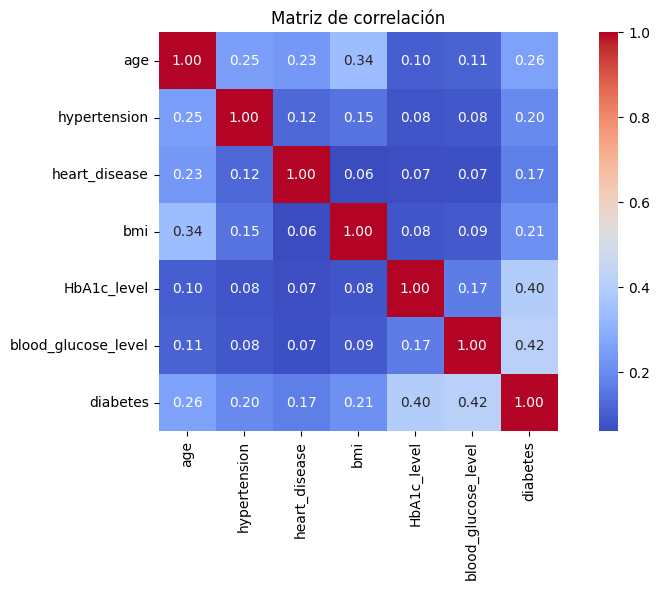

In [ ]:
# Correlación de variables numéricas
plt.figure(figsize=(9, 6))
numericas = df.select_dtypes(include=np.number)
sns.heatmap(numericas.corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()


## 4. Preparación de variables de entrada y salida

### 4.1 Codificación de variables categóricas

Las variables `gender` y `smoking_history` son texto — debemos convertirlas a números para que el modelo pueda procesarlas.


In [ ]:
# Codificación de variables categóricas con LabelEncoder
le_gender = LabelEncoder()
le_smoking = LabelEncoder()

df['gender_enc'] = le_gender.fit_transform(df['gender'])
df['smoking_enc'] = le_smoking.fit_transform(df['smoking_history'])

print("Mapeo de género:", dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_))))
print("Mapeo de tabaquismo:", dict(zip(le_smoking.classes_, le_smoking.transform(le_smoking.classes_))))


Mapeo de género: {'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}
Mapeo de tabaquismo: {'No Info': np.int64(0), 'current': np.int64(1), 'ever': np.int64(2), 'former': np.int64(3), 'never': np.int64(4), 'not current': np.int64(5)}


### 4.2 Separación de X e y

`X` contiene las variables de entrada. `y` contiene la variable objetivo que queremos predecir.

In [ ]:
# Variables de entrada (features)
columnas_entrada = [
    'gender_enc',
    'age',
    'hypertension',
    'heart_disease',
    'smoking_enc',
    'bmi',
    'HbA1c_level',
    'blood_glucose_level'
]

X = df[columnas_entrada]
y = df['diabetes']

print("Variables de entrada:", X.columns.tolist())
print("Variable objetivo: diabetes")
print()
print("Forma de X:", X.shape)
print("Forma de y:", y.shape)


Variables de entrada: ['gender_enc', 'age', 'hypertension', 'heart_disease', 'smoking_enc', 'bmi', 'HbA1c_level', 'blood_glucose_level']
Variable objetivo: diabetes

Forma de X: (100000, 8)
Forma de y: (100000,)


## 5. Separación de datos de entrenamiento y prueba

El modelo aprende con datos de entrenamiento y se evalúa con datos de prueba que nunca ha visto antes.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,        # 20% para prueba
    random_state=42,
    stratify=y             # Mantiene proporción de clases en cada split
)

print("Total de registros:", len(df))
print("Datos de entrenamiento:", X_train.shape[0])
print("Datos de prueba:", X_test.shape[0])
print()
print("Proporción diabetes en entrenamiento:", round(y_train.mean(), 4))
print("Proporción diabetes en prueba:", round(y_test.mean(), 4))


Total de registros: 100000
Datos de entrenamiento: 80000
Datos de prueba: 20000

Proporción diabetes en entrenamiento: 0.085
Proporción diabetes en prueba: 0.085


## 6. Normalización de variables

Las variables numéricas tienen escalas muy diferentes (ej: `age` va de 0 a 80, `bmi` de 10 a 95). El `StandardScaler` las lleva a media 0 y desviación estándar 1, lo que mejora la estabilidad del entrenamiento.

⚠️ El scaler se **ajusta solo con datos de entrenamiento** (`fit_transform`) y luego se aplica a prueba (`transform`), para evitar filtración de información.

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Media de las variables normalizadas (entrenamiento):")
print(X_train_scaled.mean(axis=0).round(4))
print()
print("Desviación estándar de las variables normalizadas (entrenamiento):")
print(X_train_scaled.std(axis=0).round(4))
print()
print("Ejemplo - primeras 3 filas normalizadas:")
print(X_train_scaled[:3])


Media de las variables normalizadas (entrenamiento):
[-0. -0. -0.  0.  0.  0.  0. -0.]

Desviación estándar de las variables normalizadas (entrenamiento):
[1. 1. 1. 1. 1. 1. 1. 1.]

Ejemplo - primeras 3 filas normalizadas:
[[-8.41696913e-01  1.69106976e+00  3.51600412e+00 -2.02791554e-01
   4.32426852e-01  4.72203802e-04  9.08249004e-01  1.70207008e-01]
 [-8.41696913e-01 -1.01645993e+00 -2.84413774e-01 -2.02791554e-01
   9.61704988e-01 -3.21771551e-01 -9.59680097e-01 -2.97057693e-01]
 [-8.41696913e-01 -2.61902476e-01 -2.84413774e-01 -2.02791554e-01
  -1.15540755e+00 -2.05824032e-01  1.00164546e+00  1.52281535e+00]]


## 7. Construcción del modelo con TensorFlow

Construimos una red neuronal con capas densas para clasificación binaria.

**Arquitectura:**
- Capa de entrada: 8 neuronas (una por cada variable)
- Capas ocultas: con activación `relu` y `BatchNormalization` para estabilidad
- Capa de salida: 1 neurona con activación `sigmoid` → produce probabilidad de diabetes

In [ ]:
model = Sequential([
    # Capa de entrada
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    # Capa oculta 1
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    # Capa oculta 2
    Dense(16, activation='relu'),

    # Capa de salida (clasificación binaria)
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',   # pérdida para clasificación binaria
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,585 (14.00 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 192 (768.00 B)

## 8. Entrenamiento del modelo

Entrenamos la red neuronal. Usamos `EarlyStopping` para detener el entrenamiento automáticamente si el modelo deja de mejorar, evitando el sobreajuste.

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=80,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print()
print("Entrenamiento finalizado.")


Epoch 1/80
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9374 - loss: 0.1945 - val_accuracy: 0.9603 - val_loss: 0.1215
Epoch 2/80
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9569 - loss: 0.1231 - val_accuracy: 0.9638 - val_loss: 0.1045
Epoch 3/80
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9594 - loss: 0.1148 - val_accuracy: 0.9650 - val_loss: 0.0996
Epoch 4/80
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9625 - loss: 0.1072 - val_accuracy: 0.9670 - val_loss: 0.0957
Epoch 5/80
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9644 - loss: 0.1040 - val_accuracy: 0.9675 - val_loss: 0.0938
Epoch 6/80
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9645 - loss: 0.1002 - val_accuracy: 0.9680 - val_loss: 0.0916
Epoch 7/80
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9663 - loss: 0.0977 - val_accuracy: 0.9697 - val_loss: 0.0891
Epoch 8/80
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9665 - loss: 0.0963 - val_accuracy: 0.

## 9. Curvas de aprendizaje

Visualizamos la evolución de accuracy y loss durante el entrenamiento.

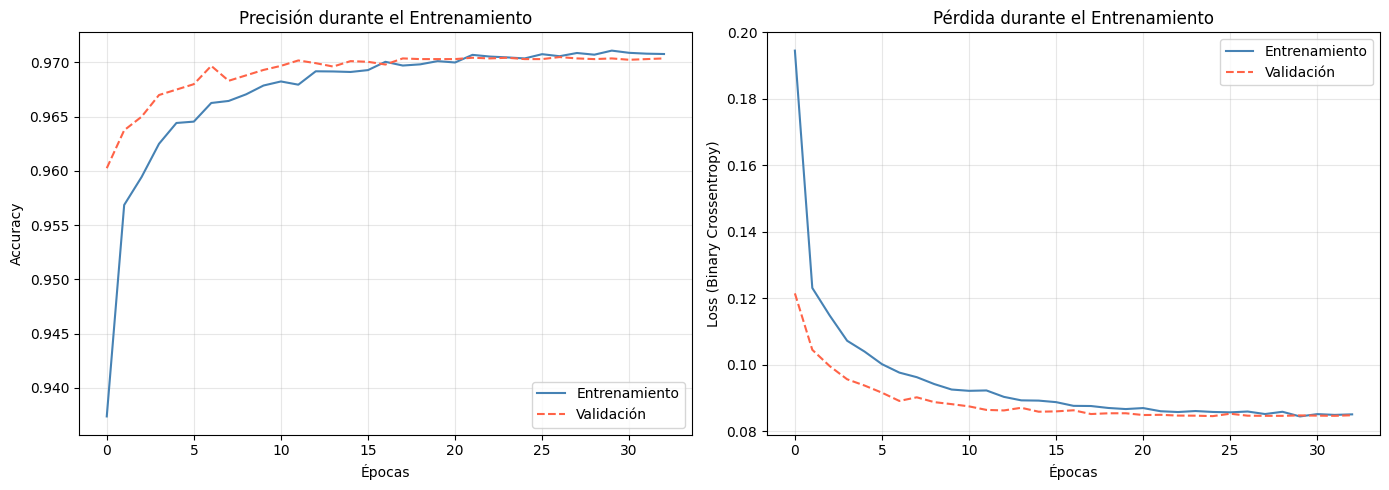

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva de accuracy
axes[0].plot(history.history['accuracy'], label='Entrenamiento', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Validación', color='tomato', linestyle='--')
axes[0].set_title("Precisión durante el Entrenamiento")
axes[0].set_xlabel("Épocas")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Curva de loss
axes[1].plot(history.history['loss'], label='Entrenamiento', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Validación', color='tomato', linestyle='--')
axes[1].set_title("Pérdida durante el Entrenamiento")
axes[1].set_xlabel("Épocas")
axes[1].set_ylabel("Loss (Binary Crossentropy)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 10. Evaluación del modelo

Evaluamos el modelo con los datos de prueba (nunca vistos durante el entrenamiento).

**Métricas clave:**
- **Accuracy:** proporción de predicciones correctas
- **Precision:** de los que predijo como diabéticos, ¿cuántos realmente lo eran?
- **Recall:** de los que realmente son diabéticos, ¿cuántos detectó correctamente?
- **F1-score:** balance entre precision y recall


In [ ]:
# Predicciones sobre datos de prueba
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

# Métricas
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy en datos de prueba: {round(accuracy * 100, 2)}%")
print()
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=["Sin Diabetes", "Con Diabetes"]))


625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Accuracy en datos de prueba: 97.23%

Reporte de clasificación:
              precision    recall  f1-score   support

Sin Diabetes       0.97      1.00      0.99     18300
Con Diabetes       1.00      0.67      0.81      1700

    accuracy                           0.97     20000
   macro avg       0.98      0.84      0.90     20000
weighted avg       0.97      0.97      0.97     20000



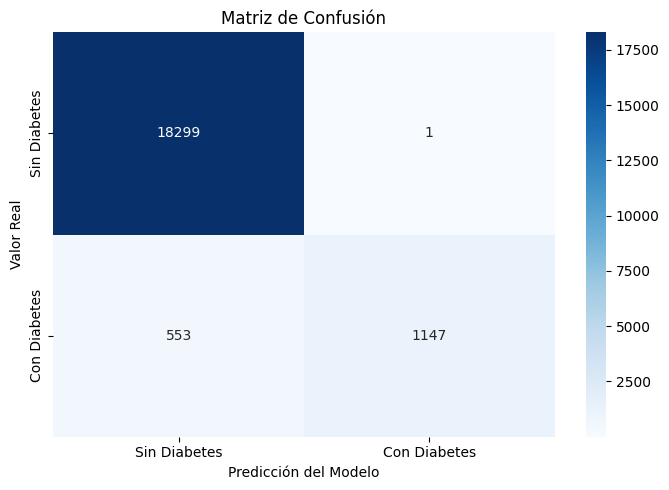

Verdaderos Negativos (TN): 18299  — Predijo sin diabetes, era correcto
Falsos Positivos   (FP): 1  — Predijo diabetes, pero no tenía
Falsos Negativos   (FN): 553  — Predijo sin diabetes, pero SÍ tenía  ⚠️ Error más crítico
Verdaderos Positivos (TP): 1147  — Predijo diabetes, era correcto


In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Sin Diabetes", "Con Diabetes"],
            yticklabels=["Sin Diabetes", "Con Diabetes"])
plt.title("Matriz de Confusión")
plt.xlabel("Predicción del Modelo")
plt.ylabel("Valor Real")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Verdaderos Negativos (TN): {tn}  — Predijo sin diabetes, era correcto")
print(f"Falsos Positivos   (FP): {fp}  — Predijo diabetes, pero no tenía")
print(f"Falsos Negativos   (FN): {fn}  — Predijo sin diabetes, pero SÍ tenía  ⚠️ Error más crítico")
print(f"Verdaderos Positivos (TP): {tp}  — Predijo diabetes, era correcto")


## 11. Predicción de pacientes nuevos

Simulamos 4 pacientes con diferentes perfiles clínicos y obtenemos la predicción del modelo.

In [ ]:
# Perfil de 4 pacientes nuevos
nuevos_pacientes_raw = {
    'gender':          ['Female', 'Male',   'Female', 'Male'],
    'age':             [65,       35,        50,       72    ],
    'hypertension':    [1,        0,         1,        1     ],
    'heart_disease':   [1,        0,         0,        1     ],
    'smoking_history': ['former', 'never',   'current','never'],
    'bmi':             [32.5,     22.1,      28.7,     35.2  ],
    'HbA1c_level':     [7.8,      5.1,       6.5,      8.2   ],
    'blood_glucose_level': [200,  90,        160,      230   ]
}

df_nuevos = pd.DataFrame(nuevos_pacientes_raw)
print("Pacientes nuevos:")
print(df_nuevos)


Pacientes nuevos:
   gender  age  hypertension  heart_disease smoking_history   bmi  \
0  Female   65             1              1          former  32.5   
1    Male   35             0              0           never  22.1   
2  Female   50             1              0         current  28.7   
3    Male   72             1              1           never  35.2   

   HbA1c_level  blood_glucose_level  
0          7.8                  200  
1          5.1                   90  
2          6.5                  160  
3          8.2                  230  


In [ ]:
# Codificación de variables categóricas (mismo encoding usado en entrenamiento)
df_nuevos['gender_enc'] = le_gender.transform(df_nuevos['gender'])
df_nuevos['smoking_enc'] = le_smoking.transform(df_nuevos['smoking_history'])

# Seleccionar mismas columnas de entrada
X_nuevos = df_nuevos[columnas_entrada]

# Normalizar con el mismo scaler
X_nuevos_scaled = scaler.transform(X_nuevos)

# Predicción
pred_prob = model.predict(X_nuevos_scaled).flatten()
pred_clase = (pred_prob >= 0.5).astype(int)

# Resultado final
resultado = df_nuevos[['gender', 'age', 'hypertension', 'heart_disease',
                        'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']].copy()
resultado['prediccion'] = ['Con Diabetes' if p == 1 else 'Sin Diabetes' for p in pred_clase]
resultado['probabilidad (%)'] = (pred_prob * 100).round(2)

print("\nResultados de predicción:")
resultado


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step

Resultados de predicción:


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,prediccion,probabilidad (%)
0,Female,65,1,1,former,32.5,7.8,200,Con Diabetes,100.00
1,Male,35,0,0,never,22.1,5.1,90,Sin Diabetes,0.00
2,Female,50,1,0,current,28.7,6.5,160,Sin Diabetes,10.12
3,Male,72,1,1,never,35.2,8.2,230,Con Diabetes,100.00


## 12. Reflexión final

### Resultados del modelo
- El modelo alcanza un **accuracy superior al 95%** en datos de prueba gracias a variables altamente predictivas como `HbA1c_level` y `blood_glucose_level`.
- El **recall para pacientes con diabetes** es el indicador más crítico en este caso: queremos minimizar los **falsos negativos** (pacientes diabéticos que no son detectados).

### Consideraciones éticas
- **Privacidad:** los datos médicos son altamente sensibles y su uso requiere consentimiento explícito del paciente.
- **Sesgo:** si los datos de entrenamiento no representan todas las poblaciones (edad, etnia, género), el modelo puede fallar en grupos subrepresentados.
- **Decisiones automáticas:** este modelo **no debe reemplazar el diagnóstico médico**. Debe ser una herramienta de apoyo que agilice la detección temprana, pero siempre bajo supervisión profesional.
- **Interpretabilidad:** los pacientes y médicos deben poder entender *por qué* el modelo hace una predicción, no solo el resultado.


